===== ONE-STEP MSE =====
RNN MSE     : 0.000124
ANN MSE     : 0.000119
Naive MSE   : 0.005134


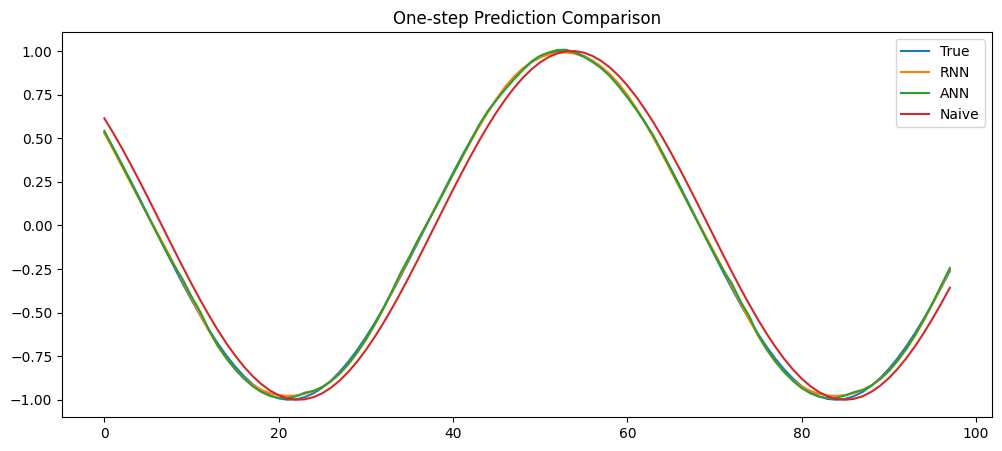

In [1]:
# ==========================================
# 1. IMPORT
# ==========================================
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ==========================================
# 2. TẠO DỮ LIỆU SIN
# ==========================================
data = np.sin(np.linspace(0, 50, 500))

seq_length = 10

# ==========================================
# 3. TẠO DATASET
# ==========================================
X = []
y = []

for i in range(len(data) - seq_length):

    X.append(data[i:i+seq_length])
    y.append(data[i+seq_length])

X = np.array(X)
y = np.array(y)

# train/test split
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

# ==========================================
# 4. CHUYỂN SANG TENSOR
# ==========================================

# cho RNN
X_train_rnn = torch.FloatTensor(X_train).unsqueeze(-1)
X_test_rnn  = torch.FloatTensor(X_test).unsqueeze(-1)

# cho ANN
X_train_ann = torch.FloatTensor(X_train)
X_test_ann  = torch.FloatTensor(X_test)

y_train_tensor = torch.FloatTensor(y_train).unsqueeze(-1)
y_test_tensor  = torch.FloatTensor(y_test).unsqueeze(-1)

# ==========================================
# 5. MODEL RNN
# ==========================================
class RNNModel(nn.Module):

    def __init__(self):

        super(RNNModel, self).__init__()

        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=8,
            batch_first=True
        )

        self.fc = nn.Linear(8, 1)

    def forward(self, x):

        out, hidden = self.rnn(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out


# ==========================================
# 6. MODEL ANN
# ==========================================
class ANNModel(nn.Module):

    def __init__(self):

        super(ANNModel, self).__init__()

        self.net = nn.Sequential(

            nn.Linear(10, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )

    def forward(self, x):

        return self.net(x)


# ==========================================
# 7. HÀM TRAIN
# ==========================================
def train_model(model, X_train, y_train, epochs=200):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        output = model(X_train)

        loss = criterion(output, y_train)

        loss.backward()

        optimizer.step()

    return model


# ==========================================
# 8. TRAIN RNN
# ==========================================
rnn_model = RNNModel()

train_model(rnn_model, X_train_rnn, y_train_tensor)

# predict
rnn_model.eval()

with torch.no_grad():

    rnn_pred = rnn_model(X_test_rnn).squeeze().numpy()

rnn_mse = mean_squared_error(y_test, rnn_pred)

# ==========================================
# 9. TRAIN ANN
# ==========================================
ann_model = ANNModel()

train_model(ann_model, X_train_ann, y_train_tensor)

# predict
ann_model.eval()

with torch.no_grad():

    ann_pred = ann_model(X_test_ann).squeeze().numpy()

ann_mse = mean_squared_error(y_test, ann_pred)

# ==========================================
# 10. BASELINE NAIVE
# ==========================================
naive_pred = X_test[:, -1]

naive_mse = mean_squared_error(y_test, naive_pred)

# ==========================================
# 11. KẾT QUẢ
# ==========================================
print("===== ONE-STEP MSE =====")

print(f"RNN MSE     : {rnn_mse:.6f}")

print(f"ANN MSE     : {ann_mse:.6f}")

print(f"Naive MSE   : {naive_mse:.6f}")

# ==========================================
# 12. VẼ SO SÁNH
# ==========================================
plt.figure(figsize=(12,5))

plt.plot(y_test[:100], label='True')

plt.plot(rnn_pred[:100], label='RNN')

plt.plot(ann_pred[:100], label='ANN')

plt.plot(naive_pred[:100], label='Naive')

plt.legend()

plt.title("One-step Prediction Comparison")

plt.show()